## 6.2 랭그래프 활용

### 6.2.1 루프 구현하기

In [1]:
# %%capture --no-stderr
# %pip install -U langgraph
# %pip install -U langchain-openai
# %pip install -U python-dotenv

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
from dotenv import load_dotenv
import os

# .env 파일에서 환경 변수 로드
load_dotenv("D:\WorkSpace\Python\langchain-tutorial\Ch05. GraphRAG")

False

In [4]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


# 실습에서 사용할 그래프의 상태값 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]

# 실습에서 사용할 그래프 정의
graph_builder = StateGraph(State)

d:\WorkSpace\Python\langchain-tutorial\Ch06. LangGraph\venv\lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [5]:
from langchain_openai import ChatOpenAI

# 오픈AI 클라이언트 정의
llm = ChatOpenAI(model="gpt-4o-mini")

# 오픈AI를 호출하여 응답을 받아 온 뒤, 상태값에 저장하여 반환하는 챗봇 함수 정의
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# 챗봇 노드 정의
graph_builder.add_node("chatbot", chatbot)

d:\WorkSpace\Python\langchain-tutorial\Ch06. LangGraph\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from langgraph.graph import StateGraph, START, END
# 진입지점
graph_builder.add_edge(START, "chatbot")
# 종료지점
graph_builder.add_edge("chatbot", END)

In [7]:
graph = graph_builder.compile()

In [8]:
while True:
    # 사용자의 질의 입력받음
    user_input = input("User: ")
    print("User:", user_input)

    # 사용자가 quit 혹은 exit 혹은 q를 입력했다면 루프 종료
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    # 사용자의 입력을 그래프에 입력하여 정의된 흐름 실행
    for event in graph.stream({"messages": ("user", user_input)}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


User: q
Goodbye!


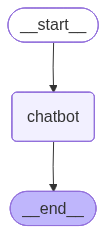

In [9]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

### 6.2.2 조건문 구현하기

In [10]:
# %%capture --no-stderr
# %pip install -U tavily-python
# %pip install -U langchain_community

In [11]:
from dotenv import load_dotenv

# .env 파일에서 환경 변수 로드
load_dotenv("/content/.env")

False

In [12]:
from langchain_community.tools.tavily_search import TavilySearchResults

# Tavily검색 엔진을 도구로 정의
tool = TavilySearchResults(max_results=2, tavily_api_key="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")
tools = [tool]
tool.invoke("내일 대한민국 서울의 날씨는?")

C:\Users\an9383\AppData\Local\Temp\ipykernel_4880\3491263705.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2, tavily_api_key="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")


[{'title': '서울 실시간 날씨 정보 | 서울 공식 관광정보 웹사이트',
  'url': 'https://korean.visitseoul.net/weather',
  'content': 'SEOUL GOODS\n\n흐림\n\n검색 영역; "검색 영역 열기")\n\n### 나의찜하기\n\n찜하기는 관심 있는 여행 정보를 저장하여 서울의 주요 지역별로 탐색할 수 있는 기능입니다.\n\n나의 찜한 목록 바로가기\n\n한국어\n\n다국어 메뉴 \n\n 한국어\n English\n 日本語\n 简体中文\n 繁體中文\n русскийязыкbeta\n Malaybeta\n\nFamily Site\n\nFamily Site; "패밀리사이트 메뉴 열기") \n\n 파트너스\n STO 소개\n 의료관광\n 서울관광 아카이브\n 서울관광플라자\n 디스커버서울패스\n 서울스테이\n 다누림관광\n 서울등산관광\n 서울컨벤션뷰로\n 서울컬쳐라운지\n Visit Seoul API\n SEOUL BLEISURE\n 서울미식주간\n\n전체보기메뉴 열기버튼\n\n전체보기메뉴 열기버튼\n\n## visitseoul.net\n\n### 검색순위\n\n### 나의찜하기\n\n찜하기는 관심 있는 여행 정보를 저장하여 서울의 주요 지역별로 탐색할 수 있는 기능입니다.\n\n나의 찜한 목록 바로가기\n\n서울의 날씨\n\n홈 >  여행정보 >  서울의 날씨\n\n서울의 날씨\n\n#### 3일 예보\n\n3일 예보 표 : 항목별(오늘, 내일, 모레) 날짜, 날씨, 최저/최고기온(℃), 강수확률\n\n| 항목 | 오늘 : 2026-05-13 | 내일 : 2026-05-14 | 모레 : 2026-05-15 |\n| 날씨 | 맑음  맑음 | 맑음  맑음 | 맑음  맑음 |\n| 최저/최고기온 (℃) | 15℃ / 26℃ | 15℃ / 31℃ | 17℃ / 31℃ |\n| 강수확률 | 0% / 0% | 0% / 0% \n\n#### 대기오염 상세',
  'score': 0.8010817},
 {'tit

In [13]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages


# 그래프 상태 정의
class State(TypedDict):
    messages: Annotated[list, add_messages]


# 그래프 정의
graph_builder = StateGraph(State)

# 오픈AI 클라이언트 정의
llm = ChatOpenAI(model="gpt-4o-mini")
# 오픈AI 클라이언트에 Tavily 검색 엔진 도구를 할당
llm_with_tools = llm.bind_tools(tools)

# 챗봇 함수 정의
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# 그래프에 챗봇 노드 추가
graph_builder.add_node("chatbot", chatbot)

In [14]:
import json

from langchain_core.messages import ToolMessage


# 도구 노드로 사용될 클래스
class BasicToolNode:

    # 도구 노드에서 사용될 초기 파라미터 정의
    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    # 도구 노드가 호출되었을때의 행동 정의
    def __call__(self, inputs: dict):
        # 입력된 상태의 가장 마지막 메세지 획득
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        # 메세지의 tool_calls 에 도구호출을 위한 값들이 존재한다면 이를 활용해 도구 호출
        outputs = []
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            # 도구 호출의 결과물을 ToolMessage로 정의하여 출력값에 저장
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        # 출력값을 상태값 형식에 맞춰 반환
        return {"messages": outputs}


# 도구 노드 정의
tool_node = BasicToolNode(tools=[tool])
# 도구 노드 그래프에 추가
graph_builder.add_node("tools", tool_node)

In [15]:
from typing import Literal


# 도구노드 호출 여부를 결정하는 함수 정의
def route_tools(
        state: State,
) -> Literal["tools", "__end__"]:
    # 상태값의 가장 최근 메세지를 정의
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")

    # 가장 최근 메세지가 tool_calls 속성을 포함하고 있다면 tools 노드를 아니라면 종료지점을 반환
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"


# 챗봇 노드에 조건부 엣지를 정의
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", "__end__": "__end__"},
)

In [16]:
# 도구 노드와 챗봇 노드 연결
graph_builder.add_edge("tools", "chatbot")
# 진입지점으로 챗봇 노드 지정
graph_builder.add_edge(START, "chatbot")

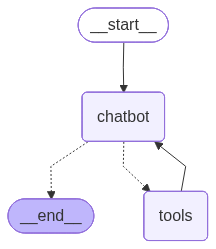

In [17]:
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### 6.2.3 스트리밍

In [18]:
from langchain_core.messages import BaseMessage

while True:
    # 사용자의 질문을 입력받습니다
    user_input = input("User: ")
    print("User:", user_input)
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break

    # 업데이트된 내용을 확인할 수 있는 그래프 스트리밍을 정의합니다.
    events = graph.stream(input={"messages": [("user", user_input)]}, stream_mode="updates")

    # 그래프 이벤트 내의 메세지를 출력합니다.
    for event in events:
        for value in event.values():
            if isinstance(value["messages"][-1], BaseMessage):
                print("Assistant:", value["messages"][-1].content)


User: q
Goodbye!


### 6.2.4 상태 저장하기

In [19]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [20]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


tool = TavilySearchResults(max_results=2, tavily_api_key="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")
tools = [tool]

llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

# 미리 빌드된 도구노드
tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

# 미리 빌드된 조건부 엣지
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# 체크포인터를 지정하여 그래프를 컴파일
graph = graph_builder.compile(checkpointer=memory)

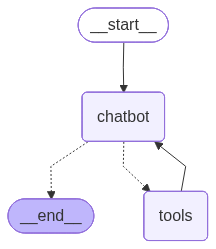

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
config = {"configurable": {"thread_id": "1"}}

In [23]:
user_input = "안녕! 내 이름은 오해원이야."

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕! 내 이름은 오해원이야.
================================== Ai Message ==================================

안녕하세요, 오해원님! 어떻게 도와드릴까요?


In [24]:
user_input = "내 이름을 기억하니?"

events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름을 기억하니?
================================== Ai Message ==================================

네, 오해원님! 기억하고 있습니다. 어떻게 도와드릴까요?


In [25]:
events = graph.stream(
    {"messages": [("user", user_input)]},
    {"configurable": {"thread_id": "2"}},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

내 이름을 기억하니?
================================== Ai Message ==================================

죄송하지만, 이전 대화 내용을 기억하거나 사용자 정보를 저장할 수 없습니다. 다시 말씀해 주시면 도와드리겠습니다!


In [26]:
snapshot = graph.get_state(config)
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='안녕! 내 이름은 오해원이야.', additional_kwargs={}, response_metadata={}, id='4aea6052-f043-4596-9f7f-099ef64efcbb'), AIMessage(content='안녕하세요, 오해원님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 90, 'total_tokens': 106, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bf1f66ac25', 'id': 'chatcmpl-Dg0x0ujJkKjUA9WflG02estUCYBAu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e2f0c-5bba-77e0-abea-e1ad00255d59-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 90, 'output_tokens': 16, 'total_tokens': 106, 'input_token_details': {'audio': 0, 'cache_read': 

### 6.2.5 루프 개입하기

In [27]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"],
)

In [28]:
user_input = "지금 서울 날씨 어때?"
config = {"configurable": {"thread_id": "2"}}
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_KcEekqDpPeq8camUUzsVQuIL)
 Call ID: call_KcEekqDpPeq8camUUzsVQuIL
  Args:
    query: current weather in Seoul


In [29]:
snapshot = graph.get_state(config)
print(snapshot.next)

('tools',)


In [30]:
from langchain_core.messages import AIMessage

# 최근 메세지
existing_message = snapshot.values["messages"][-1]
# 최근 메세지의 id
existing_message_id = existing_message.tool_calls[0]["id"]

# 강제할 응답 정의
answer = (
    "서울의 날씨는 매우 맑아요."
)

# 강제할 응답을 포함한 메세지 상태 정의
new_messages = [
    ToolMessage(content=answer, tool_call_id=existing_message_id),
    AIMessage(content=answer),
]
# 그래프 상태를 새로 작성한 메세지 상태로 변경
graph.update_state(
    config,
    {"messages": new_messages},
)


{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f150dfe-a5b6-6dbc-8005-2a2dff51d14f'}}

In [31]:
print("\n\nLast 2 messages;")
print(graph.get_state(config).values["messages"][-2:])



Last 2 messages;
[ToolMessage(content='서울의 날씨는 매우 맑아요.', id='bdf05890-c6c3-4ecc-85f5-3d29fa777773', tool_call_id='call_KcEekqDpPeq8camUUzsVQuIL'), AIMessage(content='서울의 날씨는 매우 맑아요.', additional_kwargs={}, response_metadata={}, id='f0b585a6-6851-4e00-8827-267ff0335b38', tool_calls=[], invalid_tool_calls=[])]


In [32]:
existing_message = snapshot.values["messages"][-3]
print(existing_message)

content='죄송하지만, 이전 대화 내용을 기억하거나 사용자 정보를 저장할 수 없습니다. 다시 말씀해 주시면 도와드리겠습니다!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 86, 'total_tokens': 115, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bf1f66ac25', 'id': 'chatcmpl-Dg0x3bmKg8VCvU41QQb3ddmjpPGm4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019e2f0c-6b37-75b0-bea0-7ceec47dcc59-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 86, 'output_tokens': 29, 'total_tokens': 115, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


In [33]:
from langchain_core.messages import AIMessage

user_input = "지금 서울 날씨 어때?"
config = {"configurable": {"thread_id": "3"}}
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

지금 서울 날씨 어때?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_TTWXdFqDct7KN49CAHvyxGBP)
 Call ID: call_TTWXdFqDct7KN49CAHvyxGBP
  Args:
    query: 현재 서울 날씨


In [34]:
snapshot = graph.get_state(config)
existing_message = snapshot.values["messages"][-1]
new_tool_call = existing_message.tool_calls[0].copy()
new_tool_call["args"]["query"] = "지금 경기도 날씨 어때?"
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    id=existing_message.id,
)

graph.update_state(config, {"messages": [new_message]})

{'configurable': {'thread_id': '3',
  'checkpoint_ns': '',
  'checkpoint_id': '1f150dfe-ae3d-66a9-8002-d243b40861c7'}}

In [35]:
print("\n\nLast 2 messages;")
print(graph.get_state(config).values["messages"][-2:])



Last 2 messages;
[HumanMessage(content='지금 서울 날씨 어때?', additional_kwargs={}, response_metadata={}, id='48b8b67c-91e1-40f9-ba82-d1c1ce529f57'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='lc_run--019e2f0c-76d0-7562-8eec-5d09e0087b49-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '지금 경기도 날씨 어때?'}, 'id': 'call_TTWXdFqDct7KN49CAHvyxGBP', 'type': 'tool_call'}], invalid_tool_calls=[])]
